# Clasificador paisajes
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en el Classroom como `seg_train.zip` y `seg_test.zip`. Se pide:
1. Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones).
2. Investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.
3. Normaliza
4. Diseña la arquitectura de la red. Recuerda que es un algoritmo de clasificación. Ojo con las dimensiones de la entrada
5. Reserva un 20% de los datos del entrenamiento para validar.
6. Representa el objeto history
7. Evalua el modelo con los datos de test
8. Representa algunos de los paisajes donde el modelo comete errores
9. Crea una matriz de confusión con los errores del modelo

**NOTA apartado 1**: para el apartado 1 tendras que recorre las carpetas/imagenes con `os.listdir()`, e ir cargando todas las imagenes como arrays de numpy

**NOTA apartado 4**: empieza con un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer. on softmax como ultima capa

In [21]:
import os
import pandas as pd
import numpy as np
from skimage.io import imread
import cv2

In [24]:


ROOT_PATH = r"C:\Users\NaiaJon\Documents\Naia\BootcampDataScience\Datos clase grandes\paisajes\\"

TRAIN_PATH = ROOT_PATH+ r"seg_train\\"
TEST_PATH = ROOT_PATH + r"seg_test\\"
IMAGE_WIDTH = 32

In [3]:
filenames = os.listdir(TRAIN_PATH)

In [4]:
filenames

['buildings',
 'ej_paisaje.h5',
 'forest',
 'glacier',
 'mountain',
 'sea',
 'street']

In [19]:
os.listdir (TRAIN_PATH)
#os.listdir (TRAIN_PATH+'\\'+ 'buildings'+'\\')
os.listdir (TRAIN_PATH + 'buildings')

['0.jpg',
 '10006.jpg',
 '1001.jpg',
 '10014.jpg',
 '10018.jpg',
 '10029.jpg',
 '10032.jpg',
 '10056.jpg',
 '1009.jpg',
 '10113.jpg',
 '1012.jpg',
 '10126.jpg',
 '10144.jpg',
 '10151.jpg',
 '10161.jpg',
 '10165.jpg',
 '10176.jpg',
 '10184.jpg',
 '10185.jpg',
 '10191.jpg',
 '10196.jpg',
 '10198.jpg',
 '10205.jpg',
 '10210.jpg',
 '10228.jpg',
 '10231.jpg',
 '10251.jpg',
 '10252.jpg',
 '10257.jpg',
 '10266.jpg',
 '10278.jpg',
 '1028.jpg',
 '10295.jpg',
 '10303.jpg',
 '10306.jpg',
 '10310.jpg',
 '10312.jpg',
 '10316.jpg',
 '10318.jpg',
 '10328.jpg',
 '10350.jpg',
 '10357.jpg',
 '10362.jpg',
 '10367.jpg',
 '10374.jpg',
 '10383.jpg',
 '10402.jpg',
 '1041.jpg',
 '10421.jpg',
 '10444.jpg',
 '1045.jpg',
 '10452.jpg',
 '10466.jpg',
 '10480.jpg',
 '10485.jpg',
 '10489.jpg',
 '10495.jpg',
 '10499.jpg',
 '10500.jpg',
 '10502.jpg',
 '10511.jpg',
 '10520.jpg',
 '10528.jpg',
 '1055.jpg',
 '10553.jpg',
 '10559.jpg',
 '10570.jpg',
 '10576.jpg',
 '1058.jpg',
 '10582.jpg',
 '10598.jpg',
 '10608.jpg',
 '10

In [ ]:
# Ahora cargamos las imágenes

# Reutilizo la función de la teoría pero ahora tiene que recorrer las carpetas para sacar de ahí las imagenes
# Conste 

def read_data(path, im_size):
    X = []
    Y = []

    ##### CODE #####
    # Iterar sobre todo lo que haya en path
    for folder in os.listdir (path):
        for file in os.listdir (os.path.join(path, folder)):  
            # Leer la imagen a color y aplicarle el resize
            image = imread (os.path.join(path, folder, file))
            smallimage = cv2.resize(image, (im_size, im_size))
        
        
            # Guardo en X
            X.append(smallimage)
        
            category = folder
            # Miro si es perro y gato para guardar en Y
            match category: 
                case 'buildings':
                    Y.append(0)
                case 'forest':
                    Y.append(1)
                case 'glacier':
                    Y.append (2)
                case 'mountain':
                    Y.append (3)
                case 'sea':
                    Y.append (4)
                case 'street':
                    Y.append (5)
    return np.array(X), np.array(Y)

In [28]:
X_train, y_train = read_data(TRAIN_PATH, IMAGE_WIDTH)
X_test, y_test = read_data(TEST_PATH, IMAGE_WIDTH)

print(X_train.shape)
print(X_test.shape)

(14034, 32, 32, 3)
(3000, 32, 32, 3)


2. Investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.

In [29]:
import matplotlib.pyplot as plt

(32, 32, 3)


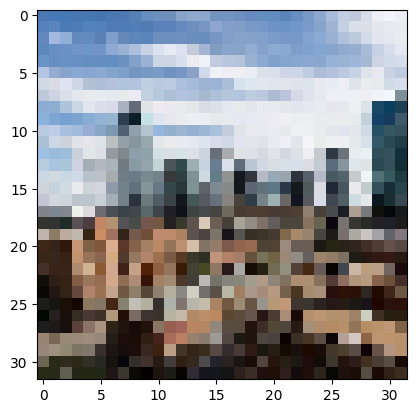

In [31]:
print(X_train[1].shape)
plt.imshow(X_train[1]);
#(si es capaz de distinguir algo con esto...)

3. Normaliza


In [32]:
# Dividimos entre 255
X_train = X_train / 255.0
X_test = X_test / 255.0

4. Diseña la arquitectura de la red. Recuerda que es un algoritmo de clasificación. Ojo con las dimensiones de la entrada


In [36]:
IMAGE_WIDTH=32
IMAGE_HEIGHT=32
IMAGE_CHANNELS=3
IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)
BATCH_SIZE = 32
EPOCHS = 30

In [ ]:
# Primero voy a desordenar los datos porque ahora vienen en orden
from sklearn.utils import shuffle
X_train, y_train = shuffle(X_train, y_train, random_state=42)

In [37]:
# He cogido el mismo diseño de la teoría. Solo cambiando el 1 de la capa de salida por un 6 porque ahora tenemos 6 
# categorías
from tensorflow import keras

layers = [
    #convolucion (64 neuronas y 3x3 en este caso) seguido de pooling
    keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=IMAGE_SIZE), 
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    
    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    # La clasificacion ya no es binaria. son 6 clases .
    keras.layers.Dense(6, activation='sigmoid') 
]

model = keras.Sequential(layers)


c:\Users\NaiaJon\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:

model.compile(optimizer = 'adam',
             loss = 'sparse_categorical_crossentropy',
             metrics = ['accuracy'])

5. Reserva un 20% de los datos del entrenamiento para validar.


In [39]:
# defino los callbacks para que no se eternice
from keras.callbacks import EarlyStopping
# si en 10 epochs no ha mejorado
earlystop = EarlyStopping(patience=10)
from keras.callbacks import ModelCheckpoint
# para que vaya guardando en 'callback_model.keras'  segun ejecuta por si el ordenador peta. Podría volver a cargar 
# el modelo 
mcheckpoint = ModelCheckpoint("callback_model.keras")

In [40]:
history = model.fit(X_train,
         y_train,
         epochs = EPOCHS,
         batch_size = BATCH_SIZE,
         callbacks = [earlystop, mcheckpoint],
         validation_split = 0.2) # reservo el 20% de los datos para validación

Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5560 - loss: 1.1155 - val_accuracy: 0.6430 - val_loss: 0.8825
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6921 - loss: 0.8223 - val_accuracy: 0.7086 - val_loss: 0.7816
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7377 - loss: 0.7152 - val_accuracy: 0.7200 - val_loss: 0.7410
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7727 - loss: 0.6234 - val_accuracy: 0.7488 - val_loss: 0.7021
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8032 - loss: 0.5528 - val_accuracy: 0.7488 - val_loss: 0.7106
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8293 - loss: 0.4729 - val_accuracy: 0.7531 - val_loss: 0.6904
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8507 - loss: 0.4160 - val_accuracy: 0.7699 - val_loss: 0.6782
Epoch 8/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8744 - loss: 0.3537 - val_accu

In [ ]:
# accuracy en train es super alto pero en validación cae bastante. Parece que no generaliza nada bien

6. Representa el objeto history


<Axes: >

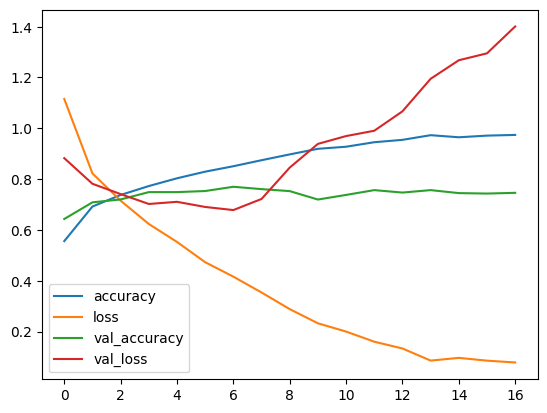

In [41]:
pd.DataFrame(history.history).plot()

In [ ]:
# Se comprueba lo de arriba

7. Evalua el modelo con los datos de test


In [42]:
results = model.evaluate(X_test, y_test)
print("test loss, test acc:", results)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7520 - loss: 1.2664
test loss, test acc: [1.2664296627044678, 0.7519999742507935]


8. Representa algunos de los paisajes donde el modelo comete errores


In [43]:
# Predecimos
predicciones = model.predict(X_test)
clases_predichas = np.argmax(predicciones, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [45]:
# cuales son errores?
indices_errores = []
for i in range (len(y_test)):
    if clases_predichas[i] != y_test[i]:
        indices_errores.append(i)

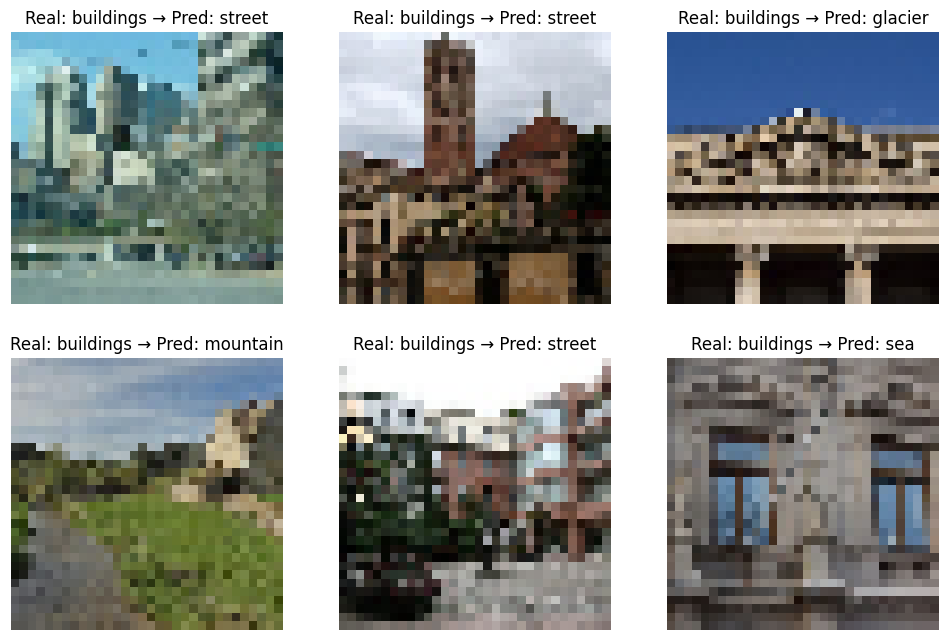

In [48]:
# Que me imprima los seis primeros
# Me mapeo las clases a las etiquetas para que se vea bien el gráfico
nombre_a_num = {
    'buildings': 0,
    'forest': 1,
    'glacier': 2,
    'mountain': 3,
    'sea': 4,
    'street': 5
}
num_a_nombre = {
    0: 'buildings',
    1: 'forest',
    2: 'glacier',
    3: 'mountain',
    4: 'sea',
    5: 'street'
}
plt.figure(figsize=(12, 12))

for i in range(min(6, len(indices_errores))):
    idx = indices_errores[i]
    
    plt.subplot(3, 3, i+1)
    plt.imshow(X_test[idx])
    real = num_a_nombre[y_test[idx]]      # Convierte número a nombre
    predicho = num_a_nombre[clases_predichas[idx]]  # Convierte número a nombre
    plt.title(f'Real: {real} → Pred: {predicho}')
    plt.axis('off')

plt.show()

9. Crea una matriz de confusión con los errores del modelo

In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, clases_predichas)
cm

array([[254,  21,  21,  19,  31,  91],
       [ 10, 424,  12,   1,   1,  26],
       [  8,   3, 447,  53,  29,  13],
       [  8,   5, 105, 370,  32,   5],
       [ 15,   4, 104,  36, 338,  13],
       [ 39,  10,  17,   6,   6, 423]])

In [ ]:
# Donde se equivoca más:
# 91 buildings los identifica como street
# 105 montañas las identifica como glaciar
# 104 mar las identifica como glaciar

In [ ]:
# A preguntar (para que no se me olvide) El modelo tiene mucho overfitting. Además de por ejemplo meterle las imágenes alteradas o algo así,
# hay parámetros que se puedan modificar? Se suele reentrenar bajando los epochs? Haciendo las redes menos complejas?